In [1]:
%cd ../../python

/home/du/work/uspas_llrf/llrf_fw/python


In [2]:
from llrf_app.app import LLRFApp
from pprint import pprint
import matplotlib.pyplot as plt
from utils import calc_ps, plot_ps
import time

%load_ext autoreload
%autoreload 2

# Program bitstream file

Connect 1320 MHz, 0dBm to zest clock input

In [3]:
!make -C ../top/marble_zest/ system_config MARBLE_SERIAL=40 GIT_32BIT_ID=6fa0c193 FSET=AWA

make: Entering directory '/home/du/work/uspas_llrf/llrf_fw/top/marble_zest'
Makefile:44: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 40
openocd \
-c "adapter serial 000040;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_AWA.6fa0c193.bit; exit"
Open On-Chip Debugger 0.12.0+dev-01158-g56d67dac2 (2025-08-25-18:54)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Warn : DEPRECATED: auto-selecting transport "jtag". Use 'transport select jtag' to suppress this message.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] Examinat

# Read Board Support info

In [25]:
llrf = LLRFApp(addr='192.168.19.40:803',
               conf='AWA',
               loopback_test=True,
               chan_keep=0b1011)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :     -9.6 mV
  Power      :     43.7 mW
  Vbus       :     11.6 V
  Current    :   -996.9 mA
INA219 U17, FMC1:
  Vshunt     :     27.5 mV
  Power      :     53.5 mW
  Vbus       :     11.6 V
  Current    :    193.0 mA
INA219 U32, FMC2:
  Vshunt     :    -26.1 mV
  Power      :     47.2 mW
  Vbus       :     11.6 V
  Current    :    127.7 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01111111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
SI570:
  regs       :    b'\xE0\xC3\x02\x01\x02\x6E'
  HSDIV      :    11
  N1         :    4
  f_reset    :     125.000 MHz
  f_xtal_hz  :     114.285 MHz
  f_out_hz   :     125.000 MHz
Zest Clocks:
  Freq  ADC0_DIV :   94.286 MHz
  Freq  ADC1_DIV :   94.286 MHz
  Freq  DAC_DCO  :  188.572 MHz
  Freq  DSP_CLK  :   94.288 MHz
  Phase ADC0_DIV :    0.227 UI
  Phase ADC1_DIV :    

In [26]:
pprint(llrf.model.cal_factors)

LLRFCalibrations(rx_gain=np.float64(3.1007519113860766),
                 tx_gain=np.float64(1.5467913671470754),
                 rx_phase_off_deg=np.float64(78.71256179570715),
                 tx_phase_off_deg=np.float64(59.99999999999996),
                 rx_dds_omega_deg=np.float64(76.36363636363636),
                 tx_dds_omega_deg=np.float64(38.18181818181818),
                 cic_wfm_gain=np.complex128(8.009853207531657+0j),
                 inlk_gain=np.complex128(0.8243942459715423+0j),
                 inlk_tx_gain=np.complex128(0.06633567165334475-0.4613747305672234j),
                 rx_iq_gain=np.complex128(1.8829406989238788+0j),
                 tx_iq_gain=np.complex128(0.13367541642597494+0.9297329430731083j),
                 max_adc_input=31129.6,
                 max_dac_drive=31129.6,
                 max_amp_setpoint=np.float64(20125.273945261208))


## Measure a snapshot of RF amplitude and phases

* In open loop, set `amp_setpoint` to drive DAC output level at 20000 counts.
* The scaling factor of `tx_gain` is applied, which is the ratio from `amp_setpoint` to DAC output.
* The `max_amp_setpoint` is the maximum value of `amp_setpoint` before saturation.

Note that the DAC IF frequency is reprogrammed to match ADC IF in oder to have a loopback test without the analog frequency converters.

In [27]:
llrf.init_open_loop_demo(2e4)

An array of calibrated, complex RF levels at base-band are available by `llrf.get_rfmon()` function, which applies the `inlk_gain` and `inlk_tx_gain` to ADC and DAC channels respectively.

In [28]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,2,-49138,2.426024,-134.961548
adc1,2,-32458,2.426024,-89.148560
adc2,0,36366,0.000000,0.000000
adc3,9813,-22517,11903.285410,-61.844788
adc4,0,-65226,0.000000,-0.000000
adc5,2,-32458,2.426024,-89.148560
adc6,2,-65226,2.426024,-179.148560
adc7,2,36366,2.426024,99.882202
dac0,9322,-29791,19999.178260,-0.005243
dac1,9322,-29791,19999.178260,-0.005243


Confirm MO phase is aligned

In [29]:
mo_adc_chan = llrf.read_reg('prl_adc_chan')
fdbk_adc_chan = llrf.read_reg('fdbk_adc_chan')
mo_adc = f'adc{mo_adc_chan}'
fdbk_adc = f'adc{fdbk_adc_chan}'
print(f'MO ADC = {mo_adc}, FDBK ADC = {fdbk_adc}')

MO ADC = adc0, FDBK ADC = adc3


## Plot raw DAC / ADC data

In [30]:
df_sig = llrf.get_raw_bufs_df()

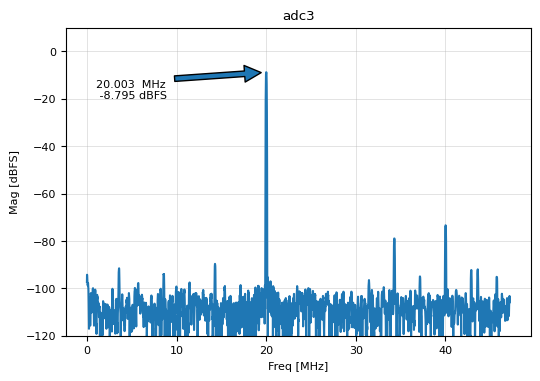

In [31]:
f, psd_dbfs = calc_ps(df_sig[fdbk_adc], fs_mhz=1e3/llrf.model.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title=fdbk_adc, annotate=True)

# Pulse mode test

In [32]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.model.DSP_CLK_CYCLE)
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 377 counts


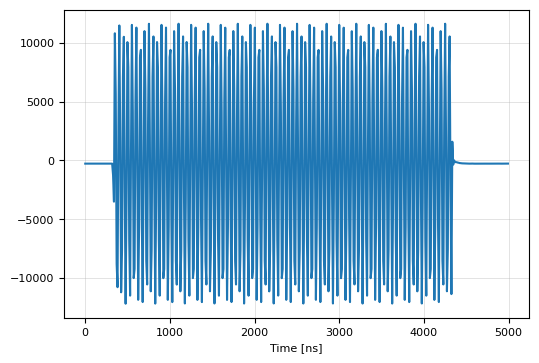

In [33]:
df_sig = llrf.get_raw_bufs_df()
df_sig[fdbk_adc].loc[:5000].plot();

In [34]:
df_iq = llrf.get_iq_wfms_df()

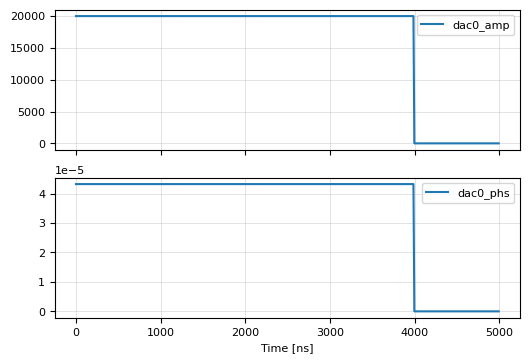

In [35]:
len_ns = 5000
fig, axes = plt.subplots(2, sharex=True)
df_iq[['dac0' + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[['dac0' + '_phs']].loc[:len_ns].plot(ax=axes[1]);


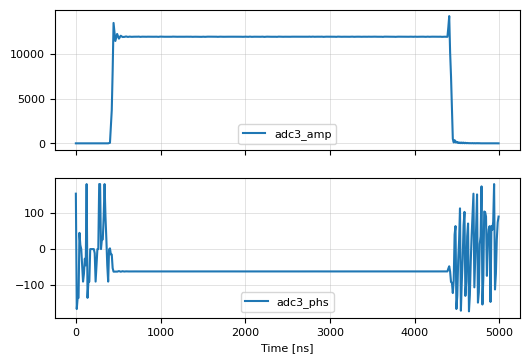

In [36]:
fig, axes = plt.subplots(2, sharex=True)
df_iq[[fdbk_adc + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[[fdbk_adc + '_phs']].loc[:len_ns].plot(ax=axes[1]);


## Plot CIC circular buffer data

In [37]:
df_mp = llrf.get_cic_wfm_df()

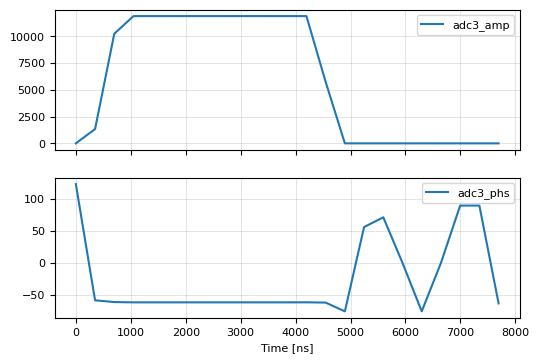

In [38]:
len_ns = 8000
fig, axes = plt.subplots(2, sharex=True)
df_mp[fdbk_adc + '_amp'].loc[:len_ns].plot(ax=axes[0], legend=True)
df_mp[fdbk_adc + '_phs'].loc[:len_ns].plot(ax=axes[1], legend=True);